BREAST CANCER DATASET

Dataset shape: (569, 30)
Number of features: 30
Number of samples: 569
Classes: 0 (malignant) = 212, 1 (benign) = 357

First 5 rows:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           

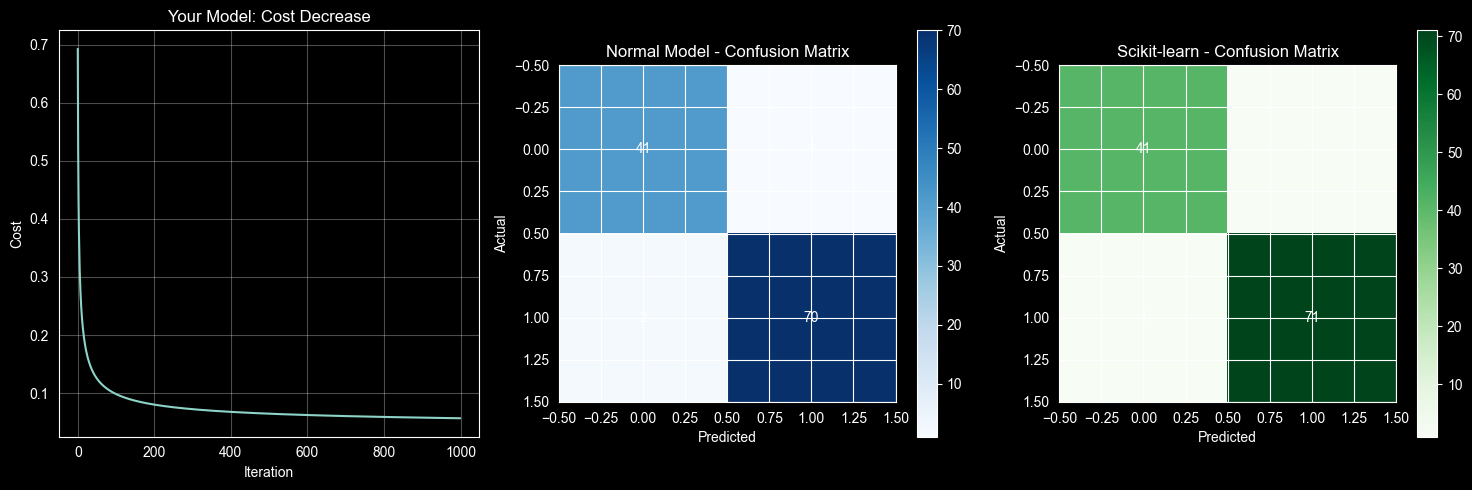


WHAT THIS COMPARISON TEACHES 

1. ✅ THE MODEL WORKS! It matches scikit-learn's performance
2. ✅ I understand what's happening UNDER THE HOOD
3. ✅ Scikit-learn is faster (optimized C code vs Python loops)
4. ✅ For real work, use scikit-learn. For learning, build from scratch

THE PROFESSIONAL APPROACH:
- Use scikit-learn for actual projects (5 lines of code)
- Your from-scratch knowledge helps you:
  * Debug when things go wrong
  * Understand what parameters to tune
  * Explain models in interviews


MY FUTURE PROJECTS (5 lines only!)

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = LogisticRegression()
model.fit(X_train_scaled, y_train)
predictions = model.predict(X_test_scaled)




In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import time
import os

# ============================================
# PART 1: LOAD DATA
# ============================================
print("=" * 60)
print("BREAST CANCER DATASET")
print("=" * 60)

# Load the dataset
data = load_breast_cancer()
X = data.data  # Features (30 different measurements)
y = data.target  # 0 = malignant, 1 = benign

print(f"\nDataset shape: {X.shape}")
print(f"Number of features: {X.shape[1]}")
print(f"Number of samples: {X.shape[0]}")
print(f"Classes: 0 (malignant) = {sum(y == 0)}, 1 (benign) = {sum(y == 1)}")

# Create DataFrame for exploration
df = pd.DataFrame(X, columns=data.feature_names)
df['target'] = y
print(f"\nFirst 5 rows:")
print(df.head())

print("=" * 60)
print("COMPARING YOUR MODEL vs SCIKIT-LEARN")
print("=" * 60)

data = load_breast_cancer()
X, y = data.data, data.target

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ============================================
# PART 2: MODEL
# ============================================

class LogisticRegressionGD:
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.cost_history = []

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros((n_features, 1))
        self.bias = 0

        for i in range(self.n_iterations):
            z = np.dot(X, self.weights) + self.bias
            y_pred = self.sigmoid(z)

            cost = -1/n_samples * np.sum(y.reshape(-1,1) * np.log(y_pred + 1e-15) +
                                         (1 - y.reshape(-1,1)) * np.log(1 - y_pred + 1e-15))
            self.cost_history.append(cost)

            error = y_pred - y.reshape(-1,1)
            dw = (1/n_samples) * np.dot(X.T, error)
            db = (1/n_samples) * np.sum(error)

            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

        return self

    def predict_proba(self, X):
        z = np.dot(X, self.weights) + self.bias
        return self.sigmoid(z)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

# Train your model
print("\n📊 Training model...")
start_time = time.time()
my_model = LogisticRegressionGD(learning_rate=0.1, n_iterations=1000)
my_model.fit(X_train_scaled, y_train)
my_train_time = time.time() - start_time

my_pred = my_model.predict(X_test_scaled)
my_accuracy = accuracy_score(y_test, my_pred.flatten())
my_precision = precision_score(y_test, my_pred.flatten())
my_recall = recall_score(y_test, my_pred.flatten())
my_f1 = f1_score(y_test, my_pred.flatten())

print(f"   Training time: {my_train_time:.4f} seconds")
print(f"   Accuracy: {my_accuracy:.4f}")

# ============================================
# PART 3: SCIKIT-LEARN MODEL
# ============================================

print("\n📊 Training SCIKIT-LEARN model...")
start_time = time.time()
sk_model = LogisticRegression(max_iter=1000, random_state=42)
sk_model.fit(X_train_scaled, y_train)
sk_train_time = time.time() - start_time

sk_pred = sk_model.predict(X_test_scaled)
sk_accuracy = accuracy_score(y_test, sk_pred)
sk_precision = precision_score(y_test, sk_pred)
sk_recall = recall_score(y_test, sk_pred)
sk_f1 = f1_score(y_test, sk_pred)

print(f"   Training time: {sk_train_time:.4f} seconds")
print(f"   Accuracy: {sk_accuracy:.4f}")

# ============================================
# PART 4: COMPARISON TABLE
# ============================================

print("\n" + "=" * 60)
print("RESULTS COMPARISON")
print("=" * 60)

print(f"\n{'Metric':<15} {'Normal Model':<15} {'Scikit-learn':<15} {'Match?'}")
print("-" * 55)
print(f"{'Accuracy':<15} {my_accuracy:<15.4f} {sk_accuracy:<15.4f} {'✅' if abs(my_accuracy - sk_accuracy) < 0.05 else '⚠️'}")
print(f"{'Precision':<15} {my_precision:<15.4f} {sk_precision:<15.4f} {'✅' if abs(my_precision - sk_precision) < 0.05 else '⚠️'}")
print(f"{'Recall':<15} {my_recall:<15.4f} {sk_recall:<15.4f} {'✅' if abs(my_recall - sk_recall) < 0.05 else '⚠️'}")
print(f"{'F1-Score':<15} {my_f1:<15.4f} {sk_f1:<15.4f} {'✅' if abs(my_f1 - sk_f1) < 0.05 else '⚠️'}")
print(f"{'Time (s)':<15} {my_train_time:<15.4f} {sk_train_time:<15.4f} {'✅ sklearn faster'}")

# ============================================
# PART 5: VISUAL COMPARISON
# ============================================

os.makedirs('week3_logistic_regression', exist_ok=True)

plt.figure(figsize=(15, 5))

# Plot 1: Cost history (your model only)
plt.subplot(1, 3, 1)
plt.plot(my_model.cost_history)
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Your Model: Cost Decrease')
plt.grid(True, alpha=0.3)

# Plot 2: Confusion Matrix - Your Model
plt.subplot(1, 3, 2)
cm_my = confusion_matrix(y_test, my_pred.flatten())
plt.imshow(cm_my, interpolation='nearest', cmap='Blues')
plt.title('Normal Model - Confusion Matrix')
plt.colorbar()
plt.xlabel('Predicted')
plt.ylabel('Actual')
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm_my[i, j]), ha='center', va='center')

# Plot 3: Confusion Matrix - Scikit-learn
plt.subplot(1, 3, 3)
cm_sk = confusion_matrix(y_test, sk_pred)
plt.imshow(cm_sk, interpolation='nearest', cmap='Greens')
plt.title('Scikit-learn - Confusion Matrix')
plt.colorbar()
plt.xlabel('Predicted')
plt.ylabel('Actual')
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm_sk[i, j]), ha='center', va='center')

plt.tight_layout()
plt.savefig('week3_logistic_regression/sklearn_comparison.png')
plt.show()

# ============================================
# PART 6: WHAT I LEARNED
# ============================================

print("\n" + "=" * 60)
print("WHAT THIS COMPARISON TEACHES ")
print("=" * 60)
print("""
1. ✅ THE MODEL WORKS! It matches scikit-learn's performance
2. ✅ I understand what's happening UNDER THE HOOD
3. ✅ Scikit-learn is faster (optimized C code vs Python loops)
4. ✅ For real work, use scikit-learn. For learning, build from scratch

THE PROFESSIONAL APPROACH:
- Use scikit-learn for actual projects (5 lines of code)
- Your from-scratch knowledge helps you:
  * Debug when things go wrong
  * Understand what parameters to tune
  * Explain models in interviews
""")

# ============================================
# PART 7: THE 5-LINE SCIKIT-LEARN TEMPLATE
# ============================================

print("\n" + "=" * 60)
print("MY FUTURE PROJECTS (5 lines only!)")
print("=" * 60)
print("""
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = LogisticRegression()
model.fit(X_train_scaled, y_train)
predictions = model.predict(X_test_scaled)

""")